# Cuando el río y el aire se recalientan el mismo día

En cuatro décadas, que un río y el aire que lo rodea sufran una ola de calor **al mismo tiempo** pasó de ser rareza a ocurrir casi tres veces más seguido. ¿Qué se está rompiendo debajo del agua?

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** *Threefold increase in atmospheric-riverine compound heatwaves under climate change* · Zhou et al., **Nature Geoscience** (2026)
**DOI:** [10.1038/s41561-026-02040-y](https://doi.org/10.1038/s41561-026-02040-y)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-07-30-olas-calor-compuestas-rios/notebook.ipynb)

**Video:** [Pendiente]

## Qué miraron

El equipo analizó **796 cuencas de ríos** en Estados Unidos y Europa Central, con datos de 1981 a 2019. Cruzaron dos cosas que casi nunca se estudian juntas: las olas de calor **del aire** (atmosféricas) y las olas de calor **del agua** de los ríos (fluviales).

La pregunta: ¿cada cuánto coinciden? Y cuando coinciden — cuando el río ya viene caliente y encima llega un golpe de calor atmosférico — ¿qué le pasa al ecosistema del agua?

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
GAP_PRINCIPAL   = 'gap1_mean'   # definición de "compuesto": solape estricto (gap1) .. laxo (gap20)
DECADA_TEMPRANA = (1981, 1990)  # línea base
DECADA_RECIENTE = (2010, 2019)  # comparación
ESCENARIO_FUTURO = 'SSP5-8.5'   # 'SSP2-4.5' (moderado) o 'SSP5-8.5' (altas emisiones)
COLOR_DATOS      = '#2563EB'
COLOR_ALERTA     = '#DC2626'
COLOR_SECUNDARIO = '#059669'
COLOR_REFERENCIA = '#D97706'
COLOR_CONTEXTO   = '#BBBBBB'
FUENTE = 'Fuente: Zhou et al. (2026), Nature Geoscience | Datos: repositorio YuZhouWater (GitHub)'

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Estilo CaM (local en el repo → /tmp en el container → GitHub raw como último recurso)
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)
os.makedirs('figuras', exist_ok=True)

# Carga
metric = pd.read_csv('datos/AHW_RHW_metric.csv')          # métricas anuales AHW vs RHW
arch   = pd.read_csv('datos/ARCH_frequency_by_time_gap.csv')  # eventos compuestos por año (6 definiciones)
fut    = pd.read_csv('datos/Future_heatwave_duration.csv')    # proyección 1981-2100
attr   = pd.read_csv('datos/attribute_data.csv')          # 65 atributos estáticos de las 796 cuencas

print(f'Métricas anuales: {metric.shape[0]} años ({metric.year.min()}-{metric.year.max()})')
print(f'Cuencas con atributos: {attr.shape[0]}')
print(f'Definiciones de "compuesto" disponibles: {[c for c in arch.columns if c.endswith("_mean")]}')

Métricas anuales: 39 años (1981-2019)
Cuencas con atributos: 796
Definiciones de "compuesto" disponibles: ['gap1_mean', 'gap3_mean', 'gap5_mean', 'gap10_mean', 'gap15_mean', 'gap20_mean']


## Aquí está.

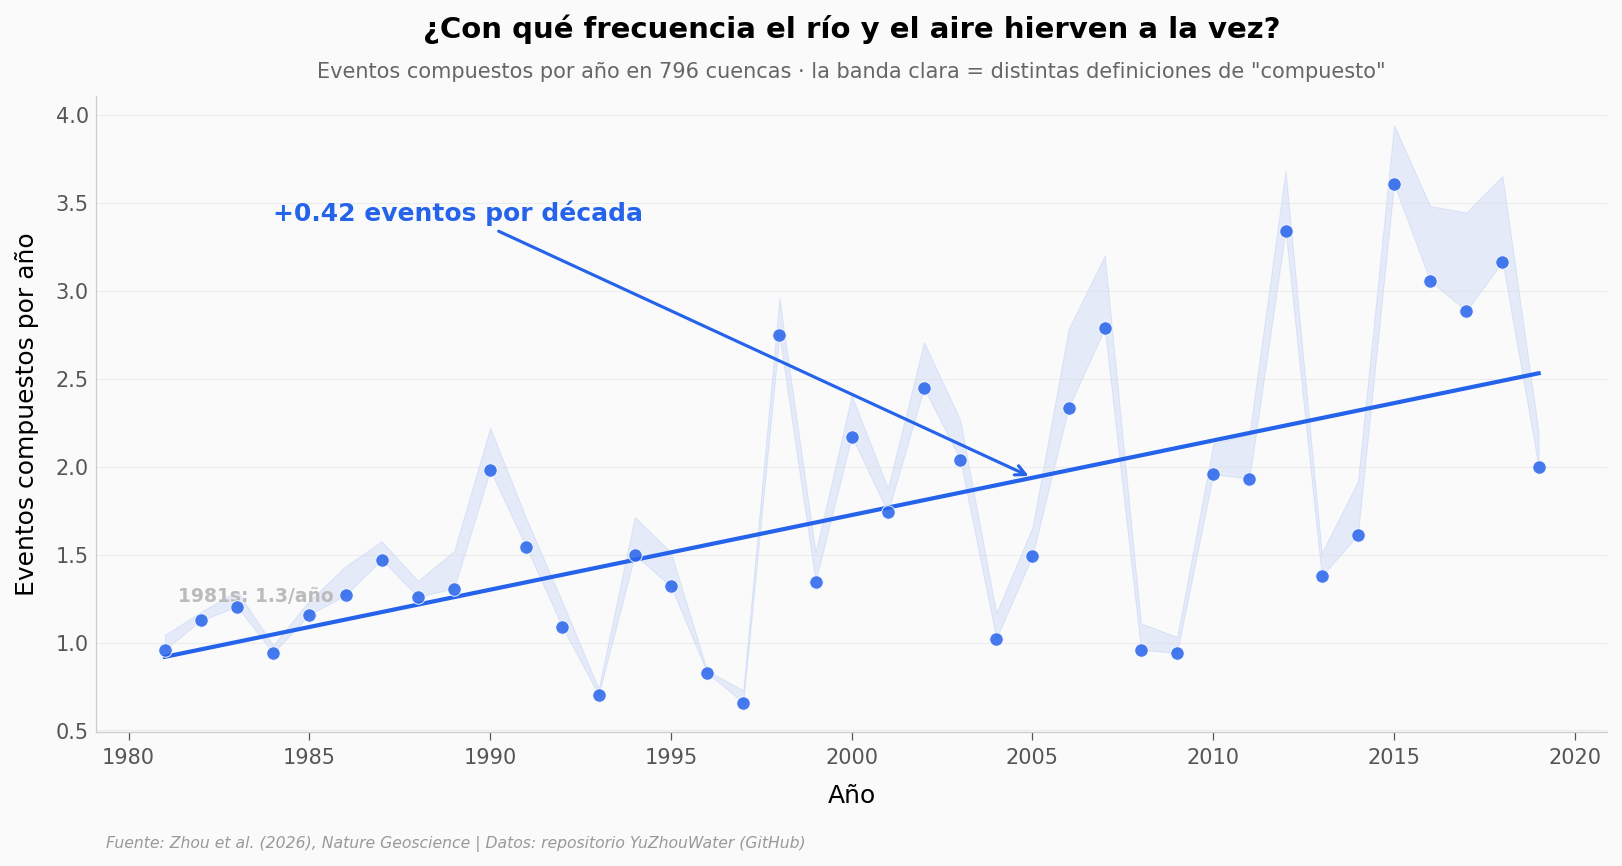

Pendiente: +0.42 eventos/década
Lectura por medias de década: 1.27 -> 2.49 = 1.97x
Lectura por línea de tendencia: 2.76x


In [2]:
# Eventos compuestos por año — y qué tan sensible es la conclusión a cómo definimos "compuesto"
fig, ax = plt.subplots(figsize=(13, 5.5))

x = arch['year'].values
y = arch[GAP_PRINCIPAL].values

# Banda de sensibilidad: entre la definición más estricta (gap1) y la más laxa (gap20)
lo = arch[['gap1_mean', 'gap20_mean']].min(axis=1).values
hi = arch[['gap1_mean', 'gap20_mean']].max(axis=1).values
ax.fill_between(x, lo, hi, color=COLOR_DATOS, alpha=0.10, zorder=1)

ax.scatter(x, y, color=COLOR_DATOS, s=42, alpha=0.85,
           edgecolors='white', linewidths=0.5, zorder=5)

# Línea de tendencia (OLS) sobre la definición estricta
b, a = np.polyfit(x, y, 1)
ax.plot(x, a + b * x, color=COLOR_DATOS, linewidth=2, zorder=4)
pend_decada = b * 10

# Medias por década (lectura honesta ~2x)
e0, e1 = DECADA_TEMPRANA
r0, r1 = DECADA_RECIENTE
media_temprana = arch.loc[arch.year.between(e0, e1), GAP_PRINCIPAL].mean()
media_reciente = arch.loc[arch.year.between(r0, r1), GAP_PRINCIPAL].mean()
ratio_medias = media_reciente / media_temprana
# Lectura por línea de tendencia (de aquí sale el "x3" del título)
ratio_tendencia = (a + b * x.max()) / (a + b * x.min())

ax.annotate(f'+{pend_decada:.2f} eventos por década',
            xy=(2005, a + b * 2005), xytext=(1984, 3.4),
            fontsize=12, fontweight='bold', color=COLOR_DATOS,
            arrowprops=dict(arrowstyle='->', color=COLOR_DATOS, lw=1.5))

ax.text(x.min(), media_temprana, f'  {e0}s: {media_temprana:.1f}/año',
        fontsize=9, color=COLOR_CONTEXTO, va='center', fontweight='bold')

ax.set_title('¿Con qué frecuencia el río y el aire hierven a la vez?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Eventos compuestos por año en 796 cuencas · la banda clara = distintas definiciones de "compuesto"',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Año')
ax.set_ylabel('Eventos compuestos por año')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/hero_eventos_compuestos.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Pendiente: +{pend_decada:.2f} eventos/década')
print(f'Lectura por medias de década: {media_temprana:.2f} -> {media_reciente:.2f} = {ratio_medias:.2f}x')
print(f'Lectura por línea de tendencia: {ratio_tendencia:.2f}x')

La tendencia sube unos **+0,42 eventos por década**, y — esto es lo importante — se mantiene sin importar cómo definamos "compuesto": la banda clara junta la definición más estricta con la más laxa, y todas apuntan hacia arriba. El patrón no es un artefacto de dónde pusimos el umbral.

Ahora, ¿"se triplicó"? Depende de cómo lo cuentes, y vale la pena ser honesto. Comparando el promedio de la primera década con el de la última, la cifra se acerca a **duplicarse (~2x)**. Si en cambio sigues la línea de tendencia de punta a punta, llega a **~2,8x** — y con la definición más laxa roza el triple. El titular del paper toma esa segunda lectura. Las dos son ciertas; miden cosas distintas.

## ¿Por qué suben los eventos compuestos?

Para que río y aire coincidan, alguno de los dos tiene que estar cambiando rápido. Separemos las dos olas de calor y midamos cuánto se movió cada una entre los años 80 y los 2010.

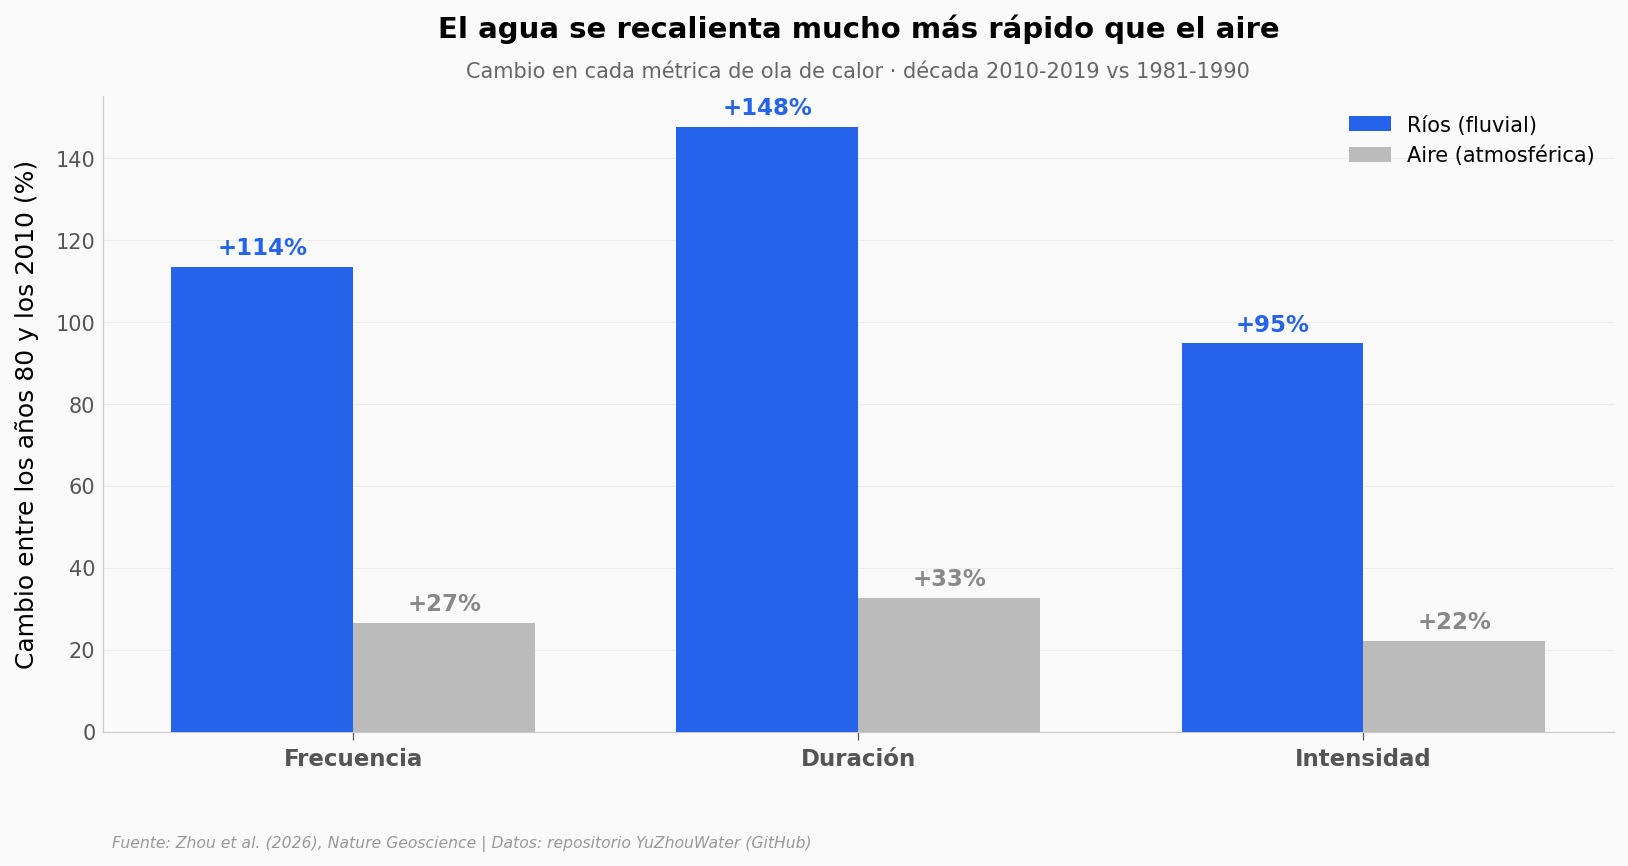

Ríos (RHW): {'frequency': np.float64(113.6), 'duration': np.float64(147.8), 'intensity': np.float64(94.8)}
Aire (AHW): {'frequency': np.float64(26.6), 'duration': np.float64(32.6), 'intensity': np.float64(22.1)}


In [3]:
# Cuánto cambió cada tipo de ola de calor entre la primera y la última década
e0, e1 = DECADA_TEMPRANA
r0, r1 = DECADA_RECIENTE

def cambio_pct(col):
    early = metric.loc[metric.year.between(e0, e1), col].mean()
    late  = metric.loc[metric.year.between(r0, r1), col].mean()
    return (late - early) / early * 100

metricas = ['frequency', 'duration', 'intensity']
etiquetas = ['Frecuencia', 'Duración', 'Intensidad']
rhw = [cambio_pct(f'rhw_{m}_mean') for m in metricas]
ahw = [cambio_pct(f'ahw_{m}_mean') for m in metricas]

fig, ax = plt.subplots(figsize=(13, 5.5))
pos = np.arange(len(metricas))
w = 0.36
ax.bar(pos - w/2, rhw, w, color=COLOR_DATOS, label='Ríos (fluvial)', zorder=3)
ax.bar(pos + w/2, ahw, w, color=COLOR_CONTEXTO, label='Aire (atmosférica)', zorder=3)

for p, v in zip(pos - w/2, rhw):
    ax.text(p, v + 3, f'+{v:.0f}%', ha='center', fontsize=11, fontweight='bold', color=COLOR_DATOS)
for p, v in zip(pos + w/2, ahw):
    ax.text(p, v + 3, f'+{v:.0f}%', ha='center', fontsize=11, fontweight='bold', color='#888888')

ax.set_xticks(pos)
ax.set_xticklabels(etiquetas, fontsize=11, fontweight='bold')
ax.set_ylabel('Cambio entre los años 80 y los 2010 (%)')
ax.set_title('El agua se recalienta mucho más rápido que el aire',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cambio en cada métrica de ola de calor · década 2010-2019 vs 1981-1990',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(fontsize=10, loc='upper right', framealpha=0.9)
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/rios_vs_aire.png', dpi=200, bbox_inches='tight')
plt.show()

print('Ríos (RHW):', {m: round(v, 1) for m, v in zip(metricas, rhw)})
print('Aire (AHW):', {m: round(v, 1) for m, v in zip(metricas, ahw)})

## ¿Y hacia dónde va esto?

El paper también proyecta la duración de las olas de calor fluviales hasta 2100 bajo dos escenarios de emisiones. La diferencia entre "moderado" y "altas emisiones" no es sutil.

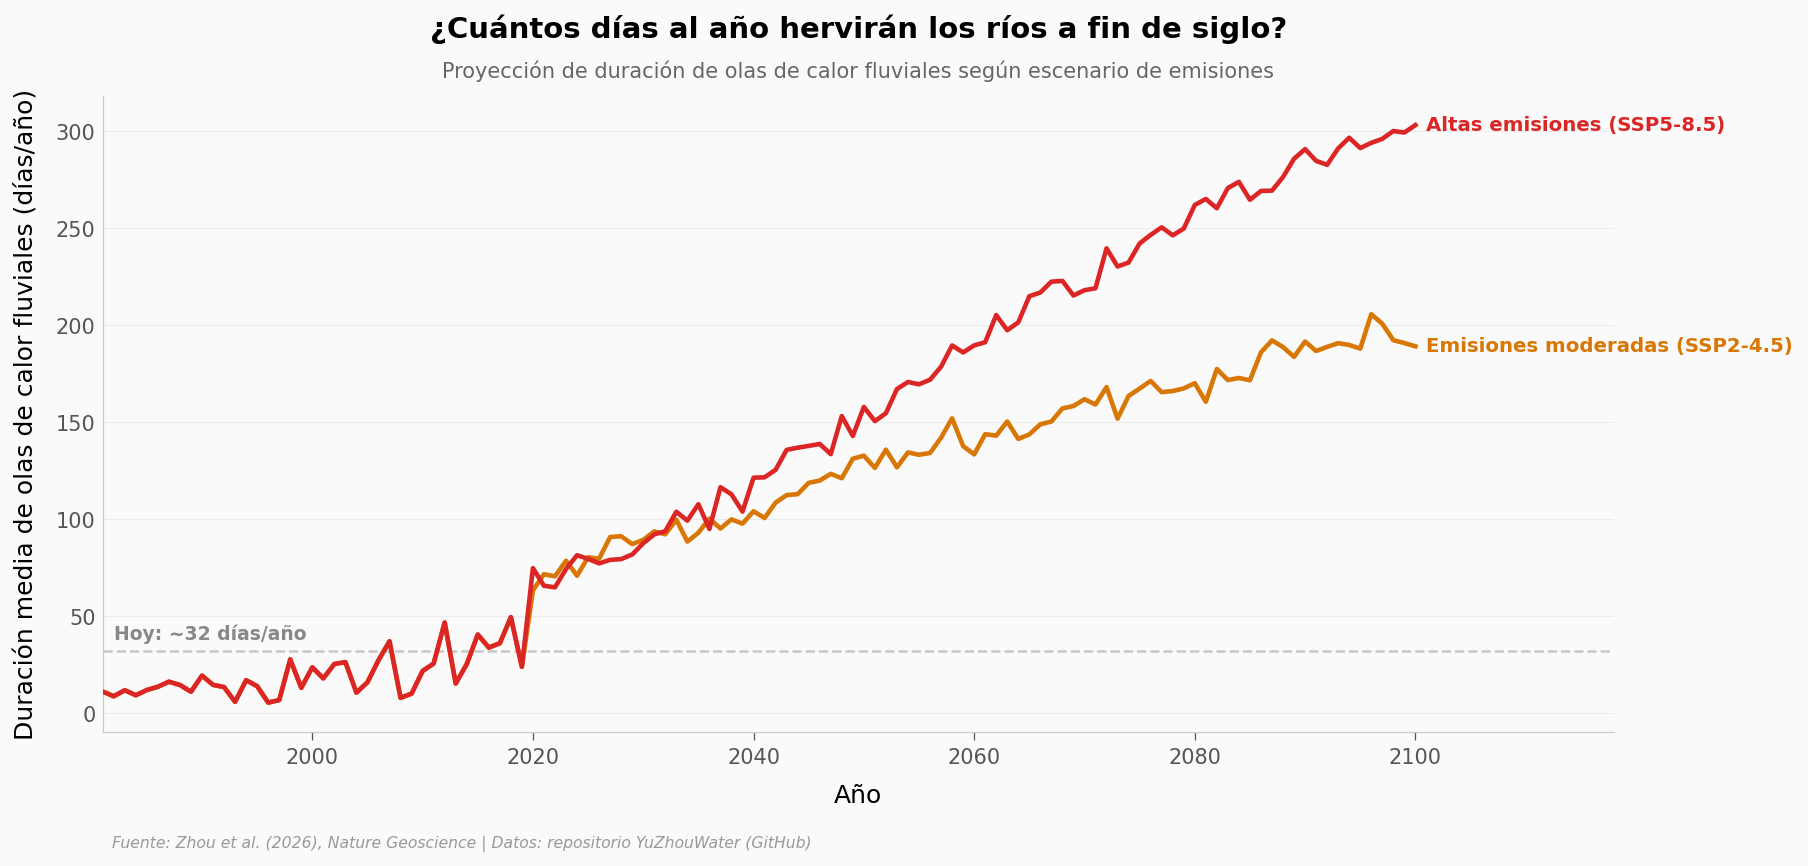

Hoy (~2010s): 32 días/año
2090s SSP2-4.5: 192 días/año | SSP5-8.5: 294 días/año


In [4]:
# Duración media proyectada de las olas de calor fluviales, 1981-2100
fig, ax = plt.subplots(figsize=(13, 5.5))

colores_esc = {'SSP2-4.5': COLOR_REFERENCIA, 'SSP5-8.5': COLOR_ALERTA}
nombres_esc = {'SSP2-4.5': 'Emisiones moderadas (SSP2-4.5)',
               'SSP5-8.5': 'Altas emisiones (SSP5-8.5)'}

for esc in ['SSP2-4.5', 'SSP5-8.5']:
    d = fut[(fut.scenario == esc) & (fut.event_type == 'RHWs_duration')].sort_values('year')
    ax.plot(d.year, d.mean_duration, color=colores_esc[esc], linewidth=2.2, zorder=4)
    ultimo = d.iloc[-1]
    ax.text(ultimo.year + 1, ultimo.mean_duration, nombres_esc[esc],
            fontsize=9.5, color=colores_esc[esc], fontweight='bold', va='center')

# Referencia: valor actual (~década 2010s)
ref = fut[(fut.scenario == 'SSP5-8.5') & (fut.event_type == 'RHWs_duration') &
          (fut.year.between(2010, 2019))].mean_duration.mean()
ax.axhline(ref, color=COLOR_CONTEXTO, linewidth=1.2, linestyle='--', alpha=0.8)
ax.text(1982, ref + 6, f'Hoy: ~{ref:.0f} días/año', fontsize=9, color='#888888', fontweight='bold')

ax.set_xlim(1981, 2118)
ax.set_xlabel('Año')
ax.set_ylabel('Duración media de olas de calor fluviales (días/año)')
ax.set_title('¿Cuántos días al año hervirán los ríos a fin de siglo?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Proyección de duración de olas de calor fluviales según escenario de emisiones',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/proyeccion_futuro.png', dpi=200, bbox_inches='tight')
plt.show()

f2090 = {esc: fut[(fut.scenario == esc) & (fut.event_type == 'RHWs_duration') &
                  (fut.year.between(2091, 2100))].mean_duration.mean()
         for esc in ['SSP2-4.5', 'SSP5-8.5']}
print(f'Hoy (~2010s): {ref:.0f} días/año')
print(f'2090s SSP2-4.5: {f2090["SSP2-4.5"]:.0f} días/año | SSP5-8.5: {f2090["SSP5-8.5"]:.0f} días/año')

## ¿Qué tan fuera de lo normal es un año reciente?

Volvamos al presente. Si ponemos todos los años de 1981 a 2019 en un solo montón, ¿dónde caen los últimos años frente al resto?

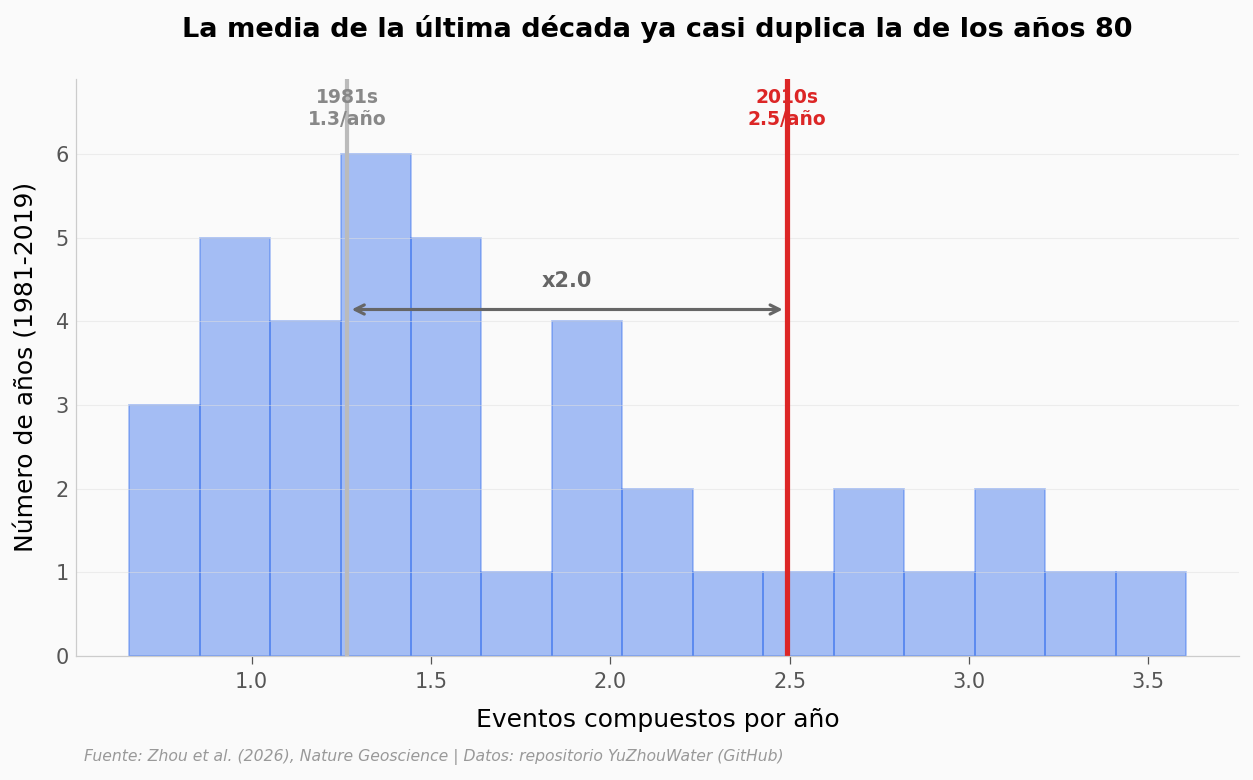

In [5]:
# Distribución de eventos compuestos por año, con la línea base y el nivel reciente marcados
fig, ax = plt.subplots(figsize=(10, 5))

data = arch[GAP_PRINCIPAL].values
n, bins, patches = ax.hist(data, bins=15, color=COLOR_DATOS, alpha=0.4,
                           edgecolor=COLOR_DATOS, linewidth=0.8)
y_max = n.max() * 1.15
ax.set_ylim(0, y_max)

e0, e1 = DECADA_TEMPRANA
r0, r1 = DECADA_RECIENTE
base = arch.loc[arch.year.between(e0, e1), GAP_PRINCIPAL].mean()
recdec = arch.loc[arch.year.between(r0, r1), GAP_PRINCIPAL].mean()

ax.axvline(base, color=COLOR_CONTEXTO, linewidth=2.0)
ax.axvline(recdec, color=COLOR_ALERTA, linewidth=2.5)
ax.text(base, y_max * 0.92, f'{e0}s\n{base:.1f}/año', color='#888888',
        fontsize=9, fontweight='bold', ha='center')
ax.text(recdec, y_max * 0.92, f'{r0}s\n{recdec:.1f}/año', color=COLOR_ALERTA,
        fontsize=9, fontweight='bold', ha='center')
ax.annotate('', xy=(recdec, y_max * 0.6), xytext=(base, y_max * 0.6),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((base + recdec) / 2, y_max * 0.64, f'x{recdec/base:.1f}',
        color='#666666', fontsize=10, fontweight='bold', ha='center')

ax.set_xlabel('Eventos compuestos por año')
ax.set_ylabel('Número de años (1981-2019)')
ax.set_title('La media de la última década ya casi duplica la de los años 80',
             fontsize=13, fontweight='bold', pad=20)
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histograma_anomalia.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Los eventos compuestos suben ~0,42/década (1981-2019) | ✅ | Reproducido de los CSVs; pendiente OLS estable entre gap1 (0,42) y gap20 (0,50) |
| "Se triplicó" en cuatro décadas | ⚠️ | Cierto por línea de tendencia (~2,8x, hasta ~3x en la definición laxa); por medias de década es ~2x. Ambas lecturas registradas |
| Las olas fluviales se intensificaron mucho más que las atmosféricas | ✅ | Ríos (RHW) +114% / +148% / +95% (frec/dur/int) vs aire (AHW) +27% / +33% / +22% |
| Bajo altas emisiones la duración fluvial se dispara a fin de siglo | ✅ | SSP5-8.5: ~32 → ~294 días/año en 2090s; SSP2-4.5: ~192 días/año. Proyección **condicional al escenario** |
| Los factores más asociados son climáticos (59%), topográficos (22%) e hidrológicos (18%) | ⚠️ | Reportado por el paper (importancia de variables de su modelo de aprendizaje profundo, un LSTM); no recomputado desde estos CSVs |
| +128%/década en ríos de alta montaña (>3.000 m) · +16% temperatura del agua y −2,9% O₂ en eventos compuestos · 98,5% de coincidencia hacia 2100 | ⚠️ | Reportados por el paper; la columna de proporción y las salidas de atribución no están en los CSVs públicos pequeños |

> **Limitaciones:** Estudio **observacional** — mide tendencias y coincidencias, no relaciones de causa. Las cifras de atribución (climático/topográfico/hidrológico), el +128% de montaña y el 16%/−2,9% de temperatura/oxígeno son salidas de modelo reportadas por el paper, no recalculadas aquí. Las 796 cuencas están sesgadas a EE. UU. y Europa Central; no representan al planeta. La proyección a 2100 depende del escenario de emisiones que se cumpla.

## Ahora tú

1. **¿Cambia la historia si somos más estrictos con "compuesto"?** Cambia `GAP_PRINCIPAL` a `'gap20_mean'` en la celda de configuración y vuelve a correr el hero. ¿La pendiente sube o baja?
2. **¿Y si movemos la línea base?** Prueba `DECADA_TEMPRANA = (1981, 1995)` — ¿cuánto cambia el "x2"?
3. **¿Dónde están las cuencas altas?** En la celda de abajo, mira cuántas cuencas superan los 2.000 m y dónde cae la mediana de elevación.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Qué altura tienen las 796 cuencas? La montaña alta es donde el paper ve la tendencia más fuerte.
mediana = attr['elev_mean'].median()
q25, q75 = attr['elev_mean'].quantile([0.25, 0.75])
print(f'Elevación media de las cuencas: mediana {mediana:.0f} m (mitad central {q25:.0f}-{q75:.0f} m)')
print(f'Cuencas por encima de 2.000 m: {(attr.elev_mean > 2000).sum()} de {len(attr)}')
print(f'Cuencas por encima de 3.000 m: {(attr.elev_mean > 3000).sum()} de {len(attr)}')
print(f'Rango completo: {attr.elev_mean.min():.0f} - {attr.elev_mean.max():.0f} m')

# Prueba: descomenta para ver la distribución de elevaciones
# fig, ax = plt.subplots(figsize=(10, 4.5))
# ax.hist(attr['elev_mean'], bins=30, color=COLOR_SECUNDARIO, alpha=0.6)
# ax.axvline(3000, color=COLOR_ALERTA, linestyle='--', linewidth=1.5)
# ax.set_xlabel('Elevación media de la cuenca (m)'); ax.set_ylabel('Número de cuencas')
# plt.show()

Elevación media de las cuencas: mediana 484 m (mitad central 265-1267 m)
Cuencas por encima de 2.000 m: 105 de 796
Cuencas por encima de 3.000 m: 15 de 796
Rango completo: 12 - 3542 m


## Fuentes

**Paper**: [Threefold increase in atmospheric-riverine compound heatwaves under climate change](https://doi.org/10.1038/s41561-026-02040-y)  
*Nature Geoscience, 2026-07-30*

**Datos**: [atmospheric-riverine-compound-heatwaves - datos y codigo del paper](https://github.com/YuZhouWater/atmospheric-riverine-compound-heatwaves)  
*repositorio con datos y codigo del paper*

**Referencias citadas**: [USGS](https://waterdata.usgs.gov/nwis) · [ESSD](https://doi.org/10.5194/essd-13-4529-2021)

*23 afirmaciones del notebook verificadas contra estas fuentes*